#### For the ages people were always saying that men from the 1st class were not saving children and women, unless men from other classes, which are considered more poor and more kind. And the aim of this EDA was to make the research and see which people are more "kind"

In [311]:
from titanic_analysis.data import (
    load_test_data,
    load_training_data,
    prepare_test_data,
)
from titanic_analysis.modeling import choose_final_model, evaluate_models
from titanic_analysis.plots import (
    plot_age_distribution,
    plot_class_survival,
    plot_correlation_heatmap,
    plot_survivor_age_distribution,
    plot_total_survival,
    plot_women_children_ratio,
)
from titanic_analysis.submission import build_submission, save_submission


In [312]:
titanic_df = load_training_data()


Firstly, it was important to know percentage survivers in every class, to make the study more objective

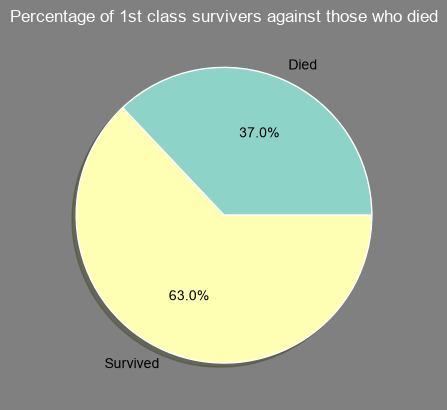

In [313]:
plot_class_survival(titanic_df, 1)


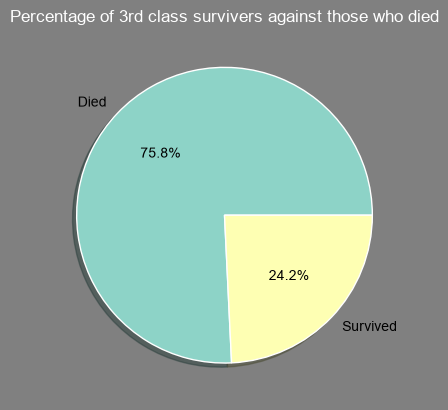

In [314]:
plot_class_survival(titanic_df, 3)


Now, the main question was about to get an answer. Next, we can get the percantage of survivers in every class

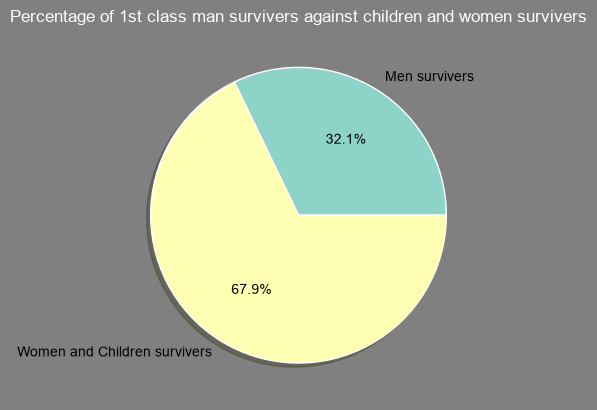

In [315]:
plot_women_children_ratio(titanic_df, 1)


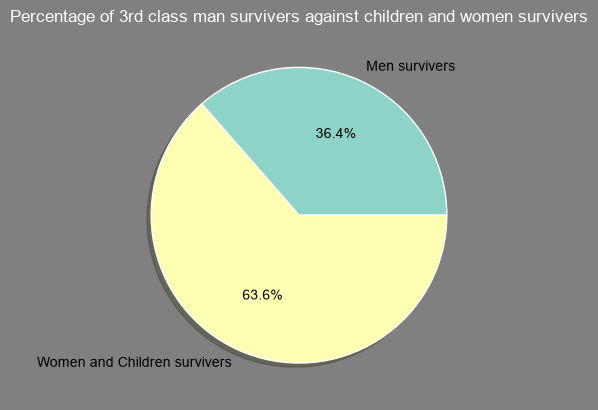

In [316]:
plot_women_children_ratio(titanic_df, 3)


Although the percentage is a bit higher in the 1st class, but we have to consider the fact that in the 1st class more people have survived, so we cannot make our decision about kindness of people

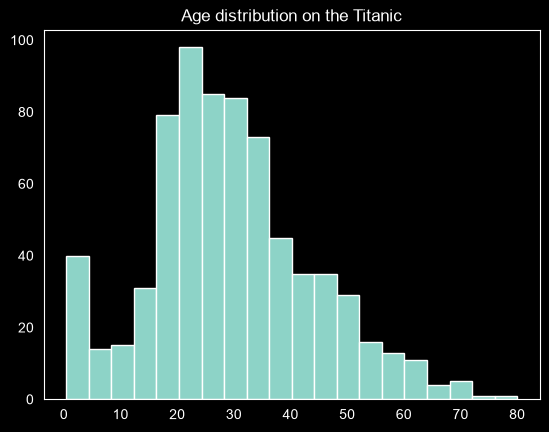

In [317]:
plot_age_distribution(titanic_df)


It was important to build to examine to see amount of people of different ages on the ship

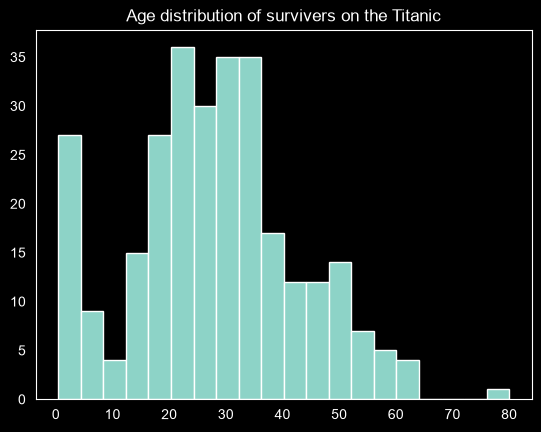

In [318]:
plot_survivor_age_distribution(titanic_df)


Then for better understanding of correlations, it was discovered how many people of different ages have survived

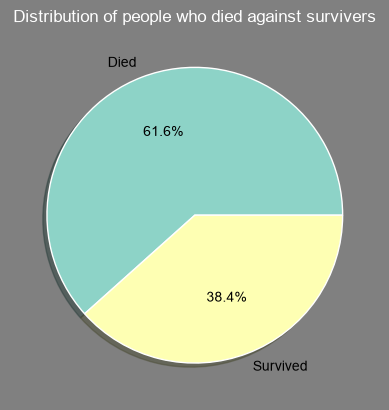

In [319]:
plot_total_survival(titanic_df)


To make a good research, pie chart of general survivers in the titanic, undependtly of other conditions, was built.

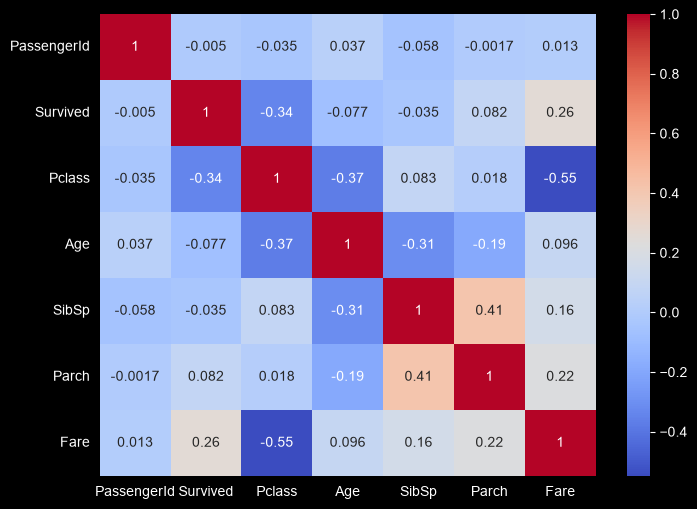

In [320]:
plot_correlation_heatmap(titanic_df)


The correlation matrix was added, to understand the dependencies in the table. It helps to choose features for building a good model.

In [321]:
# Preprocessing is learned inside model evaluation to avoid data leakage.


In [322]:
results = evaluate_models(titanic_df)
print(results["model1_accuracy"])
print(results["model1_score"])


0.8324022346368715
[0.78212291 0.81460674 0.8258427  0.79213483 0.84269663]


In [323]:
print(results["model2_accuracy"])
print(results["model2_score"])


0.8156424581005587
[0.79329609 0.80337079 0.79775281 0.7752809  0.81460674]


In [324]:
print(results["model1_score"])
print(results["model2_score"])
model_final, age_means = choose_final_model(results)


[0.78212291 0.81460674 0.8258427  0.79213483 0.84269663]
[0.79329609 0.80337079 0.79775281 0.7752809  0.81460674]


Two different models were created, evaluated, and chosen for the final csv with the predictions of survival rate

In [325]:
titanic_df_test = load_test_data()
titanic_df_test = prepare_test_data(titanic_df_test, titanic_df, age_means)


In [326]:
submission = build_submission(model_final, titanic_df_test)
save_submission(submission)


PosixPath('/Users/skyaax/PycharmProjects/TitanicDataset/submission_final_newww2.csv')

## Conclusion

Key findings:

- Sex was one of the strongest predictors of survival.
- Passenger class also had a significant impact.
- Random Forest outperformed Logistic Regression.
- The final model achieved a Kaggle score of 0.779.